In [1]:
!pip install FLASH-MM -q
!pip install scanpy -q
!pip install bioinfokit -q
!pip install gseapy matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
from bioinfokit import visuz
import matplotlib.pyplot as plt
from gseapy import dotplot
import gseapy as gp
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests
from flash_mm import lmmfit, lmmtest, contrast_matrix, sslmm, lmm
import gseapy as gp
from gseapy import barplot, dotplot
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

save_output_path = '/work/Branco/HCA_Adipose/scripts/manuscript_figures/flashmm'

# cell_type = 'ASPCs'
cell_type = 'Adipocytes'

sex_id = 'PATO:0000383'  # Female
# sex_id = 'PATO:0000384'  # Male
# sex_id = None

sex_term = 'female' if sex_id == 'PATO:0000383' else ('male' if sex_id == 'PATO:0000384' else 'all')
print(sex_term)

female


In [3]:
# Raw  object
adata = sc.read_h5ad(f'/work/Branco/HCA_Adipose/results/integration/datasets/core_atlas/core_atlas_dataset_v9_post-CAP_raw_{cell_type}.h5ad')

In [4]:
# Subset
adata = adata[adata.obs['tissue_free_text_harmonized'] != 'Cervical Subcutaneous WAT'].copy()
if sex_term != 'all':
    adata = adata[adata.obs['sex_ontology_term_id'] == sex_id].copy() 

# # non-paired data
# donor_counts = pd.crosstab(adata.obs['donor_id'], adata.obs['tissue_free_text_harmonized']) 
# unpaired_donors = donor_counts[
#     (donor_counts['Abdominal Subcutaneous WAT'] == 0) |
#     (donor_counts['Abdominal Visceral WAT'] == 0)
# ].index.tolist()
# adata = adata[adata.obs['donor_id'].isin(unpaired_donors)].copy()

# clean-up
adata.obs['tissue_free_text_harmonized'] = adata.obs['tissue_free_text_harmonized'].str.replace('Abdominal ', '').astype('category')
adata.obs['tissue_free_text_harmonized'] = adata.obs['tissue_free_text_harmonized'].str.replace(' WAT', '').astype('category')

# # Age
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('40-79', 'unknown')
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('30-49', 'unknown')
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('20-79', 'unknown')
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('40-59', 'unknown')
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('20-59', 'unknown')
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('20-49', 'unknown')
# adata.obs['age_range'] = adata.obs['age_range'].str.replace('50-79', 'unknown')
# age_ranges = list(adata.obs.age_range.unique())
# # adata = adata[adata.obs['age_range'] != 'unknown'].copy()

# # Obesity status
# def simplify_disease_term(term):
#     # Ensure term is a lowercase string for reliable matching
#     term = str(term).lower()
    
#     if 'morbid obesity' in term:
#         return 'morbid obesity'
#     elif 'obesity' in term:
#         # This catches 'obesity' and 'obesity disorder'
#         return 'obesity disorder'
#     elif 'normal' in term:
#         return 'lean'
#     else:
#         return 'lean'

# # Apply the logic to your metadata
# adata.obs['disease_simplified'] = adata.obs['disease_ontology_term'].apply(simplify_disease_term)

In [5]:
# Use gene symbols
adata.var_names = adata.var['feature_name']
adata.var_names_make_unique()

if adata.raw is not None:
    adata.X = adata.raw.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
fixed_effect = 'tissue_free_text_harmonized'
random_effect = 'donor_id' 

# Y: gene expression profile (log-transformed counts)
# Transpose Y to be (Genes x Cells)
Y = adata.X.T 
Y_names = adata.var_names.tolist()

# Ensure Y is a dense numpy array if it's currently sparse
if hasattr(Y, "toarray"):
    Y = Y.toarray()

# X: design matrix for fixed effects
# "Condition" groups
adata.obs[fixed_effect] = adata.obs[fixed_effect].astype('category')
trt_labels = adata.obs[fixed_effect].values

# Get the unique categories to ensure consistent ordering
categories = adata.obs[fixed_effect].cat.categories.tolist()

# Create the model matrix X (One-Hot Encoding)
# This creates a column for each category (e.g., A and B)
X = np.column_stack([trt_labels == cat for cat in categories]).astype(float)

# Create the names for your columns
X_names = [cat for cat in categories]

print(f"Model Matrix Shape: {X.shape}")
print(f"Columns: {X_names}")

# Z: design matrix for random effects
# Identify the column containing your random effect groups (e.g., sample IDs)
# Ensure it is categorical to maintain a stable order
samples = adata.obs[random_effect].astype('category')
sample_names = samples.cat.categories.tolist()

# Create the Z matrix (Random Effects Design Matrix)
# Each column represents one sample; 1.0 if the cell belongs to that sample, else 0.0
Z = np.column_stack([samples == s for s in sample_names]).astype(float)

# Store names for your records (useful for downstream variance analysis)
Z_names = [s for s in sample_names]

d = Z.shape[1]

print(f"Z matrix shape: {Z.shape}") # Should be (n_cells, n_samples)

# Ensure X and Z are standard numpy arrays (N_cells x N_features)
X = np.asarray(X, dtype=np.float64)
Z = np.asarray(Z, dtype=np.float64)

# Verify dimensions before fitting
print(f"Y shape (Genes, Cells): {Y.shape}")
print(f"X shape (Cells, Fixed): {X.shape}")
print(f"Z shape (Cells, Random): {Z.shape}")

# Calculate variance for each gene (rows)
gene_vars = np.var(Y, axis=1)

# Keep only genes with a variance above a tiny threshold
mask = gene_vars > 1e-6
Y = Y[mask, :]
Y_names = np.array(Y_names)[mask].tolist()

print(f"Remaining genes after variance filtering: {len(Y_names)}")

# FLASH-MM using summary statistics
method = "REML"
model_vars = X_names  

# Define contrast
c1, c2 = X_names[0], X_names[1]
contrast_name = f"{c1}_vs_{c2}"
contrast_logic = f"{c1}-{c2}"

contrast = {contrast_name: contrast_logic}
cm = contrast_matrix(contrast, model_vars)

# Fit Model
ss = sslmm(X, Y, Z)
fit = lmm(
    XX=ss["XX"], 
    XY=ss["XY"], 
    ZX=ss["ZX"], 
    ZY=ss["ZY"], 
    ZZ=ss["ZZ"], 
    Ynorm=ss["Ynorm"], 
    n=ss["n"], 
    d=[Z.shape[1]], 
    method=method, 
    Y_names=Y_names, 
    X_names=X_names,
    output_cov=True, 
    output_RE=True
)

# Run the Statistical Test
test_output = lmmtest(fit, contrast=cm)

# Results DataFrame
coef_col = f"{contrast_name}_coef"
t_stat_col = f"{contrast_name}_t"
p_val_col = f"{contrast_name}_p"

df_dea = pd.DataFrame({
    'logFC': test_output[coef_col].values,
    't_stat': test_output[t_stat_col].values,
    'p_value': test_output[p_val_col].values
}, index=Y_names)

# Multiple Testing Correction (FDR)
mask = ~df_dea['p_value'].isna()
df_dea['adj_p_val'] = np.nan
if mask.any():
    df_dea.loc[mask, 'adj_p_val'] = multipletests(df_dea.loc[mask, 'p_value'], method='fdr_bh')[1]
df_dea = df_dea.sort_values('adj_p_val')

print(f"Top Differential Genes for {contrast_name}:")
print(df_dea.head(10))

df_dea
df_dea.to_csv(f'{save_output_path}/dea_results--{sex_term}--{cell_type}--{contrast_name}--fixed_{fixed_effect}--random_{random_effect}.txt', sep='\t')

Model Matrix Shape: (147855, 2)
Columns: ['Subcutaneous', 'Visceral']
Z matrix shape: (147855, 114)
Y shape (Genes, Cells): (32159, 147855)
X shape (Cells, Fixed): (147855, 2)
Z shape (Cells, Random): (147855, 114)
Remaining genes after variance filtering: 29005


/opt/conda/lib/python3.12/site-packages/flash_mm/lmm.py:268: RuntimeWarning: invalid value encountered in sqrt
  sebeta.append(np.sqrt(np.diag(covb)))


In [ ]:
lfc_threshold = 0.25
p_threshold = 0.05

df_sig = df_dea.dropna(subset=['adj_p_val'])
up_genes = df_sig[
    (df_sig['adj_p_val'] < p_threshold) & 
    (df_sig['logFC'] > lfc_threshold)
].index.tolist()

down_genes = df_sig[
    (df_sig['adj_p_val'] < p_threshold) & 
    (df_sig['logFC'] < -lfc_threshold)
].index.tolist()

print(f"--- UP-regulated in {X_names[0]} ({len(up_genes)} genes) ---")
print("\n".join(up_genes[:20])) # Show first 20
print("\n")

print(f"--- UP-regulated in {X_names[1]} ({len(down_genes)} genes) ---")
print("\n".join(down_genes[:20])) # Show first 20

In [ ]:
# Pathway analysis
gene_sets = ['GO_Biological_Process_2023']

enr_up = gp.enrichr(gene_list=up_genes,
                    gene_sets=gene_sets,
                    organism='human',
                    outdir=None)
enr_up.results.to_csv(f'{save_output_path}/enrichr_results_upr--{sex_term}--{cell_type}--{contrast_name}--fixed_{fixed_effect}--random_{random_effect}.txt', sep='\t')

enr_down = gp.enrichr(gene_list=down_genes,
                      gene_sets=gene_sets,
                      organism='human',
                      outdir=None)
enr_down.results.to_csv(f'{save_output_path}/enrichr_results_downr--{sex_term}--{cell_type}--{contrast_name}--fixed_{fixed_effect}--random_{random_effect}.txt', sep='\t')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pandas as pd

def run_enrichr(df, title="Functional Enrichment", outdir=None):

    # --- 1. Data Prep & Sorting ---
    accent_navy = "#3D85C6"
    fdr_col = 'Adjusted P-value'
    score_col = 'Combined Score' # The new X-axis variable
    
    # Get top 10 per group
    plot_df = df.groupby('Gene_set').head(10).copy()
    plot_df['gene_percent'] = plot_df['Overlap'].apply(lambda x: eval(x) * 100)
    
    # Logic remains: BP on top, low FDR (most significant) at the top of each block
    plot_df = plot_df.sort_values(
        ['Gene_set', fdr_col], 
        ascending=[False, False] 
    )
    
    # --- 2. Setup Plot ---
    # Increased width (from 2 to 5) to allow the Combined Score scale to be readable
    fig, ax = plt.subplots(figsize=(5, 6))
    
    norm = Normalize(plot_df[fdr_col].min(), plot_df[fdr_col].max())
    cmap = sns.light_palette(accent_navy, as_cmap=True).reversed() 
    
    # --- 3. Plotting ---
    scatter = ax.scatter(
        x=plot_df[score_col], # Modified: X is now Combined Score
        y=plot_df['Term'],
        s=plot_df['gene_percent'] * 15, # Slightly increased size multiplier for visibility
        c=plot_df[fdr_col],
        cmap=cmap,
        norm=norm,
        edgecolor="0.2",
        linewidth=0.5,
        zorder=3
    )
    
    # --- 5. Labels & Scale ---
    ax.set_xlabel('Combined Score', fontweight='bold', fontsize=10)
    # Remove previous squeezing; let the scale determine limits or add a small buffer
    ax.set_xlim(left=0) 
    
    # --- 6. Legends ---
    # Colorbar
    cbar_ax = fig.add_axes([0.92, 0.7, 0.03, 0.15]) 
    sm = ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('FDR', fontsize=8, fontweight='bold')
    
    # Size Legend
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=4)
    # Corrected multiplier to match the 's' parameter above (15)
    clean_labels = [f"{float(l.split('{')[-1].split('}')[0])/15:.1f}%" for l in labels]
    ax.legend(handles, clean_labels, loc="lower left", bbox_to_anchor=(1.05, 0.05), 
              title="Gene %", frameon=False, fontsize=8,
              labelspacing=1.5)
    
    # Styling
    # Changed left=False to ensure the Y-axis (Terms) has a visible spine
    sns.despine(ax=ax, left=False, bottom=False)
    ax.grid(axis='both', linestyle=':', alpha=0.3)
    ax.set_title(title, pad=25, fontweight='bold', color=accent_navy)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar
    plt.show()

In [ ]:
run_enrichr(enr_up.results, title=f'Upr Bio Processes in {cell_type} from {sex_term}: {contrast_name}')
run_enrichr(enr_down.results, title=f'Downr Bio Processes in {cell_type} from {sex_term}: {contrast_name}')

In [ ]:
print('y')

# Results

### Female - ASPCs

/tmp/ipykernel_2027/2842626501.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar
/tmp/ipykernel_2027/2842626501.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar


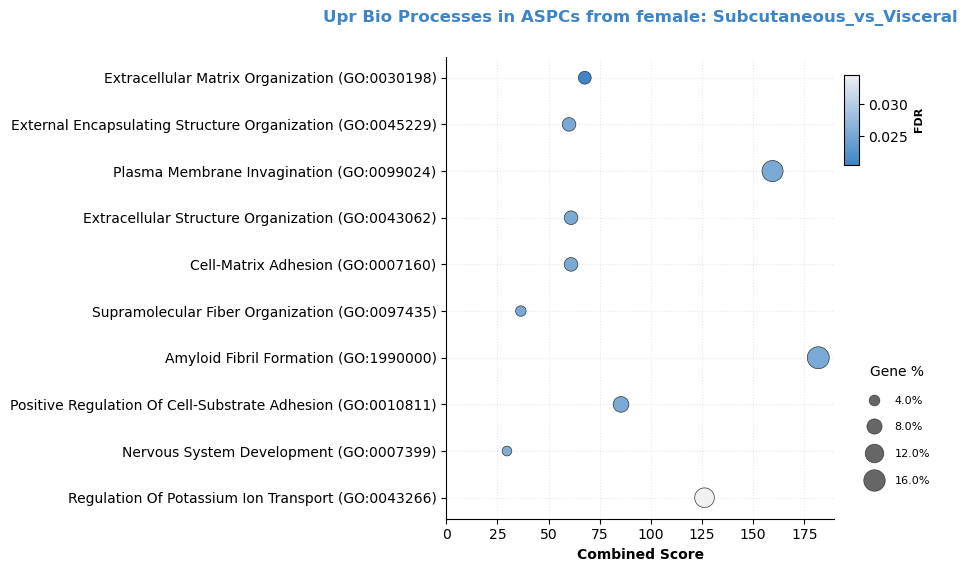

/tmp/ipykernel_2027/2842626501.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar
/tmp/ipykernel_2027/2842626501.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar


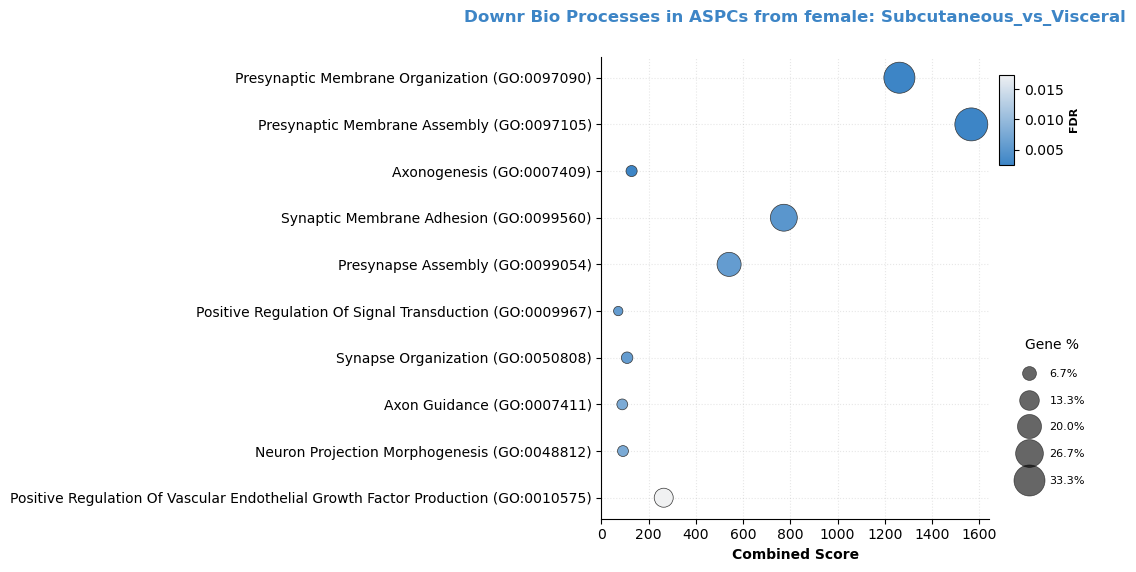

In [12]:
run_enrichr(enr_up.results, title=f'Upr Bio Processes in {cell_type} from {sex_term}: {contrast_name}')
run_enrichr(enr_down.results, title=f'Downr Bio Processes in {cell_type} from {sex_term}: {contrast_name}')

### Female - Adipocytes

/tmp/ipykernel_738/2842626501.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar
/tmp/ipykernel_738/2842626501.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar


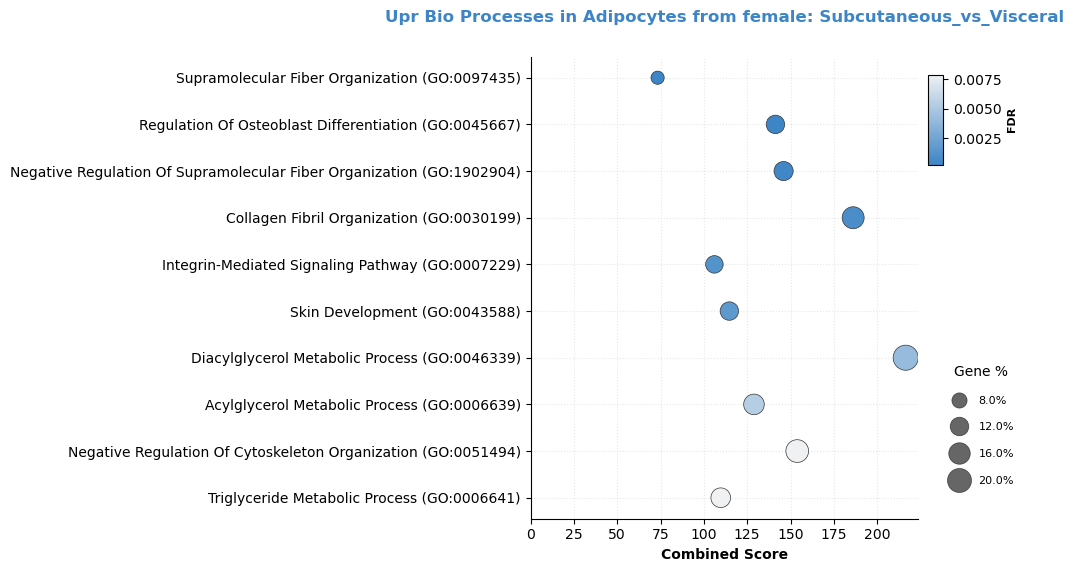

In [21]:
run_enrichr(enr_up.results, title=f'Upr Bio Processes in {cell_type} from {sex_term}: {contrast_name}')

/tmp/ipykernel_738/2842626501.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar
/tmp/ipykernel_738/2842626501.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Make room for legend/colorbar


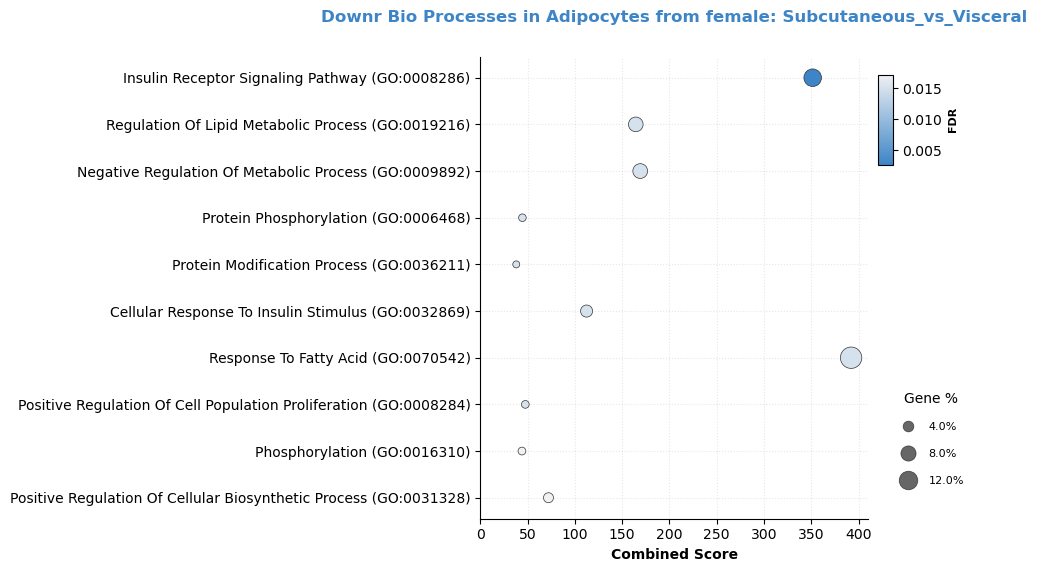

In [22]:
run_enrichr(enr_down.results, title=f'Downr Bio Processes in {cell_type} from {sex_term}: {contrast_name}')

In [23]:
sign_up = enr_up.results[enr_up.results['Adjusted P-value'] < 0.05]
for i in sign_up['Term']:
    print(i)

Supramolecular Fiber Organization (GO:0097435)
Regulation Of Osteoblast Differentiation (GO:0045667)
Negative Regulation Of Supramolecular Fiber Organization (GO:1902904)
Collagen Fibril Organization (GO:0030199)
Integrin-Mediated Signaling Pathway (GO:0007229)
Skin Development (GO:0043588)
Diacylglycerol Metabolic Process (GO:0046339)
Acylglycerol Metabolic Process (GO:0006639)
Triglyceride Metabolic Process (GO:0006641)
Negative Regulation Of Cytoskeleton Organization (GO:0051494)
Regulation Of Cell Migration (GO:0030334)
Negative Regulation Of Epithelial Cell Proliferation (GO:0050680)
Negative Regulation Of Osteoblast Differentiation (GO:0045668)
Neuron Migration (GO:0001764)
Glucan Metabolic Process (GO:0044042)
Positive Regulation Of Cell Migration (GO:0030335)
Negative Regulation Of Endothelial Cell Proliferation (GO:0001937)
Cytoskeleton Organization (GO:0007010)
Extracellular Matrix Organization (GO:0030198)
Cellular Response To Prostaglandin Stimulus (GO:0071379)
Skeletal Mus

In [24]:
sign_down = enr_down.results[enr_down.results['Adjusted P-value'] < 0.05]
for i in sign_down['Term']:
    print(i)

Insulin Receptor Signaling Pathway (GO:0008286)
Positive Regulation Of Cell Population Proliferation (GO:0008284)
Response To Fatty Acid (GO:0070542)
Cellular Response To Insulin Stimulus (GO:0032869)
Protein Modification Process (GO:0036211)
Protein Phosphorylation (GO:0006468)
Negative Regulation Of Metabolic Process (GO:0009892)
Regulation Of Lipid Metabolic Process (GO:0019216)
Positive Regulation Of Cellular Biosynthetic Process (GO:0031328)
Phosphorylation (GO:0016310)
Regulation Of Basement Membrane Organization (GO:0110011)
Regulation Of Glucose Metabolic Process (GO:0010906)
Positive Regulation Of B Cell Receptor Signaling Pathway (GO:0050861)
Regulation Of Developmental Growth (GO:0048638)
Central Nervous System Development (GO:0007417)
Positive Regulation Of Cell Differentiation (GO:0045597)
Transmembrane Receptor Protein Tyrosine Kinase Signaling Pathway (GO:0007169)
Negative Regulation Of Cell Differentiation (GO:0045596)
Regulation Of Fat Cell Differentiation (GO:0045598)

In [ ]:
# # FLASH-MM
# method = "REML"
# model_vars = X_names  

# # Define contrast
# c1, c2 = X_names[0], X_names[1]
# contrast_name = f"{c1}_vs_{c2}"
# contrast_logic = f"{c1}-{c2}"

# contrast = {contrast_name: contrast_logic}
# cm = contrast_matrix(contrast, model_vars)

# # Fit Model
# # Note: d must be a list [number_of_random_effects]
# fit = lmmfit(Y, X, Z, d=[Z.shape[1]], Y_names=Y_names, X_names=X_names, 
#              method=method, output_cov=True, output_RE=True)

# # Run the Statistical Test
# test_output = lmmtest(fit, contrast=cm)

# # Results DataFrame
# coef_col = f"{contrast_name}_coef"
# t_stat_col = f"{contrast_name}_t"
# p_val_col = f"{contrast_name}_p"

# df_dea = pd.DataFrame({
#     'logFC': test_output[coef_col].values,
#     't_stat': test_output[t_stat_col].values,
#     'p_value': test_output[p_val_col].values
# }, index=Y_names)

# # Multiple Testing Correction (FDR)
# mask = ~df_dea['p_value'].isna()
# df_dea['adj_p_val'] = np.nan
# if mask.any():
#     df_dea.loc[mask, 'adj_p_val'] = multipletests(df_dea.loc[mask, 'p_value'], method='fdr_bh')[1]
# df_dea = df_dea.sort_values('adj_p_val')

# print(f"Top Differential Genes for {contrast_name}:")
# print(df_dea.head(10))

# df_dea